# Sentiment and Text Classification using Transformers


In [1]:
!pip install google-play-scraper transformers torch pandas seaborn matplotlib scikit-learn wordcloud tqdm --quiet


from google_play_scraper import reviews
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00


In [2]:
#  Scrape only first 10,000 Google Play reviews

app_id = 'com.lenskart.app'  # Example: Lenskart
print("Fetching up to 10,000 reviews...")

reviews_data, _ = reviews(
    app_id,
    lang='en',
    country='us',
    count=10000,  # fetch only 10k
    filter_score_with=None
)

df = pd.DataFrame(reviews_data)
print(f"Total reviews collected: {df.shape[0]}")

# Keep only text content
df = df[['content']].dropna().reset_index(drop=True)
print(f"Processing {len(df)} reviews...")

Fetching up to 10,000 reviews...
Total reviews collected: 10000
Processing 10000 reviews...



Running transformer sentiment analysis...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0
100%|██████████| 10000/10000 [01:41<00:00, 98.54it/s] 
/tmp/ipython-input-2137508517.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])


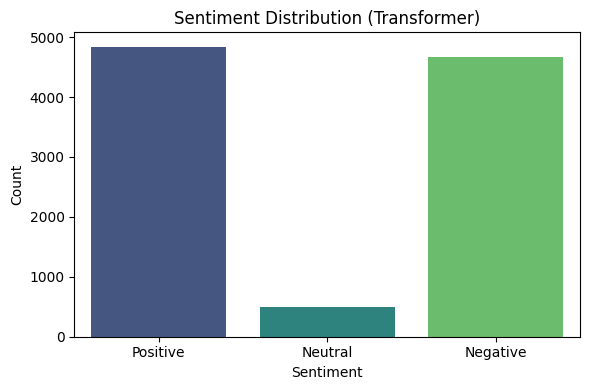

In [3]:
#  Transformer-based Sentiment Analysis

print("\nRunning transformer sentiment analysis...")
sentiment_model = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

tqdm.pandas()

def transformer_sentiment(text):
    result = sentiment_model(text[:512])[0]['label']
    score = int(result.split()[0])
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['content'].progress_apply(transformer_sentiment)


#  Visualize Sentiment Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution (Transformer)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Running transformer-based zero-shot classification...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
100%|██████████| 10000/10000 [10:52<00:00, 15.33it/s]


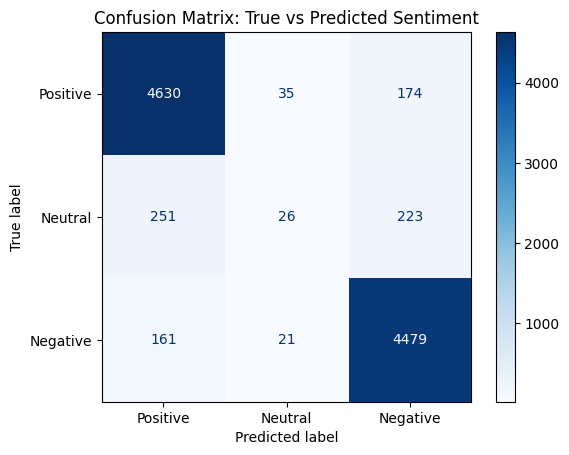


 Sentiment analysis and classification completed successfully!
                                             content sentiment  \
0  Lenskart gave a fake commitment on the very fi...  Negative   
1                                          very good  Positive   
2  Very disappointing experience. Promises and co...  Negative   
3  worst app no customer care support they are ca...  Negative   
4  very pathetic service, delivered other item th...  Negative   

  predicted_sentiment  
0            Negative  
1            Positive  
2            Negative  
3            Negative  
4            Negative  


In [4]:
#  Zero-Shot Text Classification (3 sentiment classes)

print("\nRunning transformer-based zero-shot classification...")
text_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

candidate_labels = ['Positive', 'Neutral', 'Negative']

def classify_text(text):
    result = text_classifier(text[:512], candidate_labels)
    return result['labels'][0]

df['predicted_sentiment'] = df['content'].progress_apply(classify_text)


#  Confusion Matrix (True vs Predicted)

cm = confusion_matrix(df['sentiment'], df['predicted_sentiment'], labels=['Positive', 'Neutral', 'Negative'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive', 'Neutral', 'Negative'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: True vs Predicted Sentiment')
plt.show()


#  Completion Message

print("\n Sentiment analysis and classification completed successfully!")
print(df.head())
